# 02 - MLP (Multi-Layer Perceptron)

We're moving from bigrams to MLPs.
The bigram model was cool but dumb. It only looked one character back. 
The MLP fixes this. Theres a context window (ex. 3 characters) and it actually has something to work with. 
It learns embeddings for each character, passes them through a hidden layer, and outputs probabilities for what comes next.
This is where things start feeling like real deep learning.

In [5]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import pandas as pd

In [10]:
df = pd.read_parquet('data/0000.parquet')
comments = df['Comment'].dropna().tolist()
comments = [c.lower() for c in comments]

text = ''.join(comments)
chars = sorted(list(set(text)))
vocab_size = len(chars)

len(comments)

25430

In [7]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['|'] = 0
itos = {i:s for s,i in stoi.items()}    

In [11]:
random.seed(42)
random.shuffle(comments)

n1 = int(0.8 * len(comments))
n2 = int(0.9 * len(comments))

train = comments[:n1]
val = comments[n1:n2]
test = comments[n2:]

print(len(train))
print(len(val))
print(len(test))


20344
2543
2543


In [12]:
# Building the dataset
block_size = 3
def build_dataset(comments):
    X, Y = [], []
    for comment in comments: 
        context = [0] * block_size
        for ch in comment: 
            ix =stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
        X.append(context)
        Y.append(0)
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

In [ ]:
Xtr, Ytr   = build_dataset(train)
Xval, Yval = build_dataset(val)
Xte, Yte   = build_dataset(test)

print(Xtr.shape, Ytr.shape)
print(Xval.shape, Yval.shape)
print(Xte.shape, Yte.shape)


torch.Size([3118732, 3]) torch.Size([3118732])
torch.Size([388886, 3]) torch.Size([388886])
torch.Size([395959, 3]) torch.Size([395959])


In [14]:
Xtr[:10]

tensor([[ 0,  0,  0],
        [ 0,  0, 47],
        [ 0, 47, 35],
        [47, 35, 32],
        [35, 32,  1],
        [32,  1, 28],
        [ 1, 28, 47],
        [28, 47, 47],
        [47, 47, 28],
        [47, 28, 30]])

In [27]:
Xtr.shape[0]

3118732

### Embedding : 

neural networks cannot express characters as is.. they need to be coverted into numbers for the model to learn and nudge. We must create an embedding matrix which assigns a set of values (2 for now and then we ll increase) to feed into the model for each of the character. the model learns and changes these embeddings and contextualises each character

In [15]:
C = torch.randn(74,2)

In [17]:
C[Xtr].shape

torch.Size([3118732, 3, 2])

- 3118732 training examples, each with a context window of 3 characters, each character represented by 2 embedding values.

In [19]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [20]:
W2 = torch.randn((100,74))
b2 = torch.randn(74)

In [22]:
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

8322


##### 4 standard steps in every training loop 
1. Forward pass --> compute predictions
2. Loss --> measure how wrong we are
3. Backward pass --> compute gradients
4. Update --> nudge weights

In [ ]:
for i in range(20000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]                          
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) 
    logits = h @ W2 + b2                       
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    for p in parameters:
        p.data += -0.1 * p.grad
    
print(f"final loss: {loss.item():.4f}")

final loss: 2.7857


In [31]:
for i in range(20000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(f"final loss: {loss.item():.4f}")

final loss: 1.7965


In [32]:
# train loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(f"train loss: {train_loss.item():.4f}")

# val loss
emb = C[Xval]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, Yval)
print(f"val loss: {val_loss.item():.4f}")

train loss: 2.0464
val loss: 2.0439


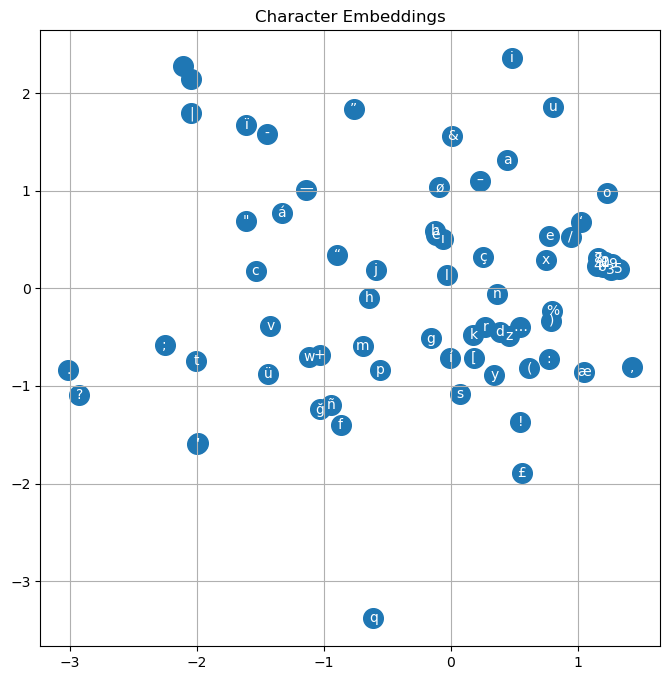

In [33]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(74):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid(True)
plt.title('Character Embeddings')
plt.show()

In [34]:
C  = torch.randn((74, 10))
W1 = torch.randn((30, 200))
b1 = torch.randn(200)
W2 = torch.randn((200, 74))
b2 = torch.randn(74)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [36]:
for i in range(20000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(f"final loss: {loss.item():.4f}")

final loss: 1.4778


In [38]:
# train loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(f"train loss: {train_loss.item():.4f}")

# val loss
emb = C[Xval]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, Yval)
print(f"val loss: {val_loss.item():.4f}")

train loss: 2.1072
val loss: 2.1097


In [62]:
#g = torch.Generator().manual_seed(42)

for _ in range(5):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
    

haby the brell calty trike a sont sons to slays right. head  25’y graw brield sict sroccsy yards!!! –0!:qz0jmsels is the just bacl[mdurst to bressioun righting his spb to poss sed throuslisslen visissessistsontro.|
alch on the sist. thois is nettersing to phock on the hims he gross ostititgulham homessists night by visilk. visd is will pross stonhsdelerdiaya llas tensidelliard no sressists treakes the siveled trat-sictsil with the giver to pre triked ts the sim.s of the man west the st! but his noenter lover, almironunis himstrisak ges spositerelloss to time othe goal, yutedsing the jysislissen the brilhk ono slisi prespr ressing just the game hostrama chos, and ever his thampessischindoup! thu brugms aressisentstons right the brikedd gonissli6k’ time: s. the has his liver justessistessisussistonhost the endorward but the slace spts midds will willeare ris stramd ing vising time: ner endisresnotham outesteskistrir. rosst box to pt the pressistrearlyenity the premier outsistres it on si